# Edge Betweenness Centrality for Network Growth Simulation

Computes edge betweenness centrality on the full street network as a
topological proxy for latent cycling demand. The BC ranking provides
a static priority ordering for the demand-driven forward growth strategy.

| Item | Detail |
|------|--------|
| **Input** | `network_lts_with_junctions.gpkg` (notebook 04) |
| **Output** | `network_lts_with_bc.gpkg`, `upgrade_candidates_bc_ranked.csv` |
| **Method** | NetworKit — C++ parallelised Brandes algorithm, orders of magnitude faster than NetworkX |

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import networkit as nk

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

DATA_DIR    = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR  = Path('../Data/Cleaned')
CRS_BNG     = 'EPSG:27700'

## 1. Load LTS-classified network

In [8]:
network = gpd.read_file(CLEANED_DIR / "network_lts_with_junctions.gpkg")

# Ensure length columns
if 'length_km' not in network.columns:
    network['length_km'] = network['geometry_length_m'].astype(float) / 1000

print(f"Directed edges: {len(network):,}")
print(f"\nLTS distribution (lts_final):")
print(network['lts_final'].value_counts().sort_index())

Directed edges: 480,228

LTS distribution (lts_final):
lts_final
1.0    227858
2.0    150941
3.0     47077
4.0     54352
Name: count, dtype: int64


## 2. Build undirected edge table

BC is computed on an undirected projection of the full street network.
Demand potential is symmetric, and the growth simulation operates on
undirected connectivity. For directed edges sharing the same node pair,
the shorter length is kept.

In [9]:
edges_for_graph = network[['from_node', 'to_node', 'geometry_length_m']].copy()
edges_for_graph['geometry_length_m'] = edges_for_graph['geometry_length_m'].astype(float)

# Canonical undirected key
edges_for_graph['u'] = edges_for_graph[['from_node', 'to_node']].min(axis=1)
edges_for_graph['v'] = edges_for_graph[['from_node', 'to_node']].max(axis=1)

# One row per undirected edge, keep min length
edges_undir = (
    edges_for_graph
    .groupby(['u', 'v'], as_index=False)['geometry_length_m']
    .min()
)
print(f"Undirected edges: {len(edges_undir):,}")

Undirected edges: 255,286


## 3. Map node IDs to contiguous integers

NetworKit requires contiguous integer node IDs starting from 0.

In [10]:
all_nodes = sorted(set(edges_undir['u']) | set(edges_undir['v']))
node_to_idx = {nid: idx for idx, nid in enumerate(all_nodes)}
idx_to_node = {idx: nid for nid, idx in node_to_idx.items()}

n_nodes = len(all_nodes)
print(f"Nodes: {n_nodes:,}")

Nodes: 253,548


## 4. Build NetworKit graph

In [11]:
G = nk.Graph(n_nodes, weighted=True, directed=False)

for _, row in edges_undir.iterrows():
    u_idx = node_to_idx[row['u']]
    v_idx = node_to_idx[row['v']]
    G.addEdge(u_idx, v_idx, row['geometry_length_m'])

print(f"NetworKit graph: {G.numberOfNodes():,} nodes, {G.numberOfEdges():,} edges")

NetworKit graph: 253,548 nodes, 255,286 edges


## 5. Compute edge betweenness centrality

NetworKit's `EdgeBetweenness` uses a parallelised Brandes algorithm.
For ~100k nodes and ~180k edges, expect 2–10 minutes (exact) versus
hours with NetworkX.

In [14]:
t0 = time.time()

G.indexEdges()
ebc = nk.centrality.Betweenness(G, normalized=True, computeEdgeCentrality=True)
ebc.run()

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s ({elapsed/60:.1f} min)")

Done in 4937.2s (82.3 min)


## 6. Extract BC scores and map to edges

In [16]:
edge_bc_scores = ebc.edgeScores()

bc_lookup = {}
def collect_edge(u_idx, v_idx, w, eid):
    u_orig = idx_to_node[u_idx]
    v_orig = idx_to_node[v_idx]
    bc_val = edge_bc_scores[eid]
    bc_lookup[(u_orig, v_orig)] = bc_val
    bc_lookup[(v_orig, u_orig)] = bc_val

G.forEdges(collect_edge)

print(f"Edge BC values extracted: {len(bc_lookup) // 2:,}")

Edge BC values extracted: 255,122


In [17]:
# Map BC to directed edge GeoDataFrame
network['bc'] = network.apply(
    lambda row: bc_lookup.get(
        (row['from_node'], row['to_node']),
        np.nan
    ),
    axis=1
)

n_matched = network['bc'].notna().sum()
n_missing = network['bc'].isna().sum()
print(f"Matched: {n_matched:,}")
print(f"Missing: {n_missing:,}")

network['bc'] = network['bc'].fillna(0.0)

Matched: 480,228
Missing: 0


## 7. Summary statistics

In [18]:
# BC by LTS level
print("Mean edge BC by LTS level:")
print(network.groupby('lts_final')['bc'].agg(['mean', 'median', 'count']).to_string())

# Upgrade candidates
candidates = network[network['lts_final'].isin([3, 4])].copy()
candidates['bc_rank'] = candidates['bc'].rank(ascending=False, method='min')

print(f"\nUpgrade candidates (LTS 3-4): {len(candidates):,}")
print(f"  LTS 3: {(candidates['lts_final'] == 3).sum():,}")
print(f"  LTS 4: {(candidates['lts_final'] == 4).sum():,}")
print(f"\nBC distribution:")
print(f"  mean   : {candidates['bc'].mean():.6e}")
print(f"  median : {candidates['bc'].median():.6e}")
print(f"  max    : {candidates['bc'].max():.6e}")

Mean edge BC by LTS level:
               mean    median   count
lts_final                            
1.0        0.000176  0.000006  227858
2.0        0.000291  0.000024  150941
3.0        0.002186  0.000425   47077
4.0        0.003943  0.000961   54352

Upgrade candidates (LTS 3-4): 101,429
  LTS 3: 47,077
  LTS 4: 54,352

BC distribution:
  mean   : 3.127314e-03
  median : 6.744476e-04
  max    : 1.352421e-01


In [19]:
# Top 20 candidates
print("Top 20 candidates by BC:\n")
top20 = candidates.nlargest(20, 'bc')[
    ['osid', 'edge_id', 'lts_final', 'length_km', 'bc', 'bc_rank']
]
print(top20.to_string(index=False))

Top 20 candidates by BC:

                                osid                                edge_id  lts_final  length_km       bc  bc_rank
5a03574a-bd7f-447a-8a07-11c95331411a 5a03574a-bd7f-447a-8a07-11c95331411a_F        4.0   0.006083 0.135242      1.0
d0a325e6-ba58-4a58-b92a-d4df0dec2d3c d0a325e6-ba58-4a58-b92a-d4df0dec2d3c_B        4.0   1.317730 0.120789      2.0
dfafa635-8936-437b-a783-7abaf3a66df1 dfafa635-8936-437b-a783-7abaf3a66df1_B        4.0   0.267878 0.120786      3.0
d2130724-eeb9-4ea8-a323-523a5abbfe88 d2130724-eeb9-4ea8-a323-523a5abbfe88_F        4.0   0.418217 0.095758      4.0
d2130724-eeb9-4ea8-a323-523a5abbfe88 d2130724-eeb9-4ea8-a323-523a5abbfe88_B        4.0   0.418217 0.095758      4.0
5ea274e6-c9a9-44e2-9bd8-3b8701812c18 5ea274e6-c9a9-44e2-9bd8-3b8701812c18_F        3.0   0.130306 0.095741      6.0
457680d5-ea60-424d-b0ad-0ee14f5505bf 457680d5-ea60-424d-b0ad-0ee14f5505bf_F        4.0   0.118163 0.095729      7.0
457680d5-ea60-424d-b0ad-0ee14f5505bf 457680d5-

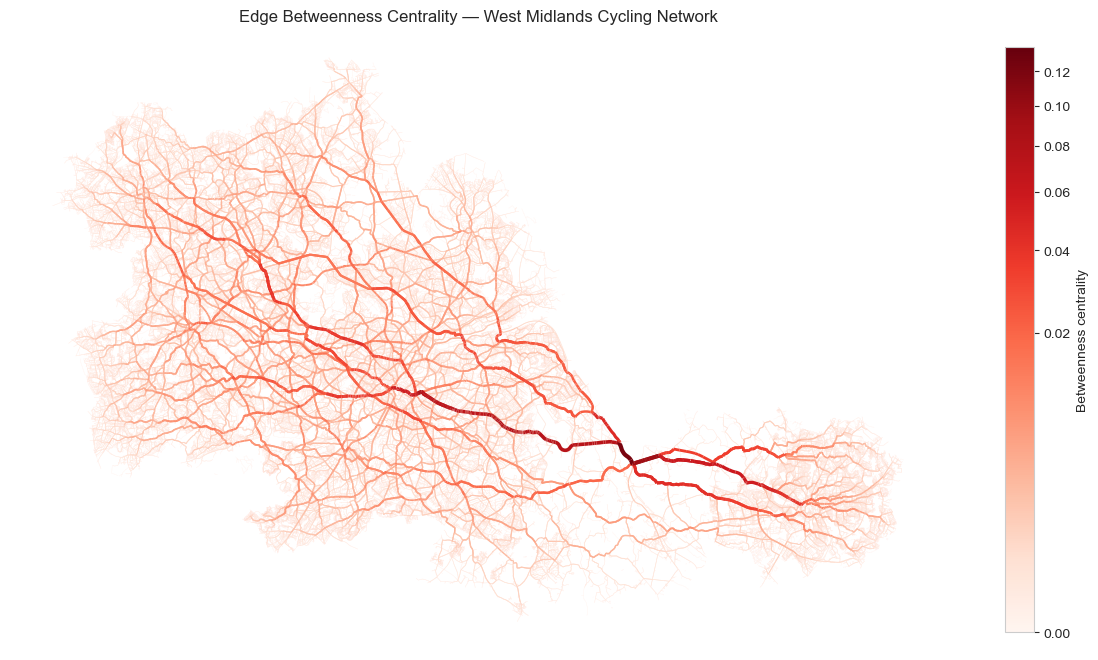

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

gdf_plot = network.sort_values("bc").copy()

bc = gdf_plot["bc"].to_numpy()
norm = mcolors.PowerNorm(gamma=0.35, vmin=bc.min(), vmax=bc.max())
t = norm(bc)                     

lw = 0.15 + t * 3.0

fig, ax = plt.subplots(figsize=(12, 12))
gdf_plot.plot(
    ax=ax,
    column="bc",
    cmap="Reds",
    norm=norm,
    linewidth=lw,
    legend=True,
    legend_kwds={"label": "Betweenness centrality", "shrink": 0.5},
)

ax.set_facecolor("white") 
ax.set_axis_off()
ax.set_title("Edge Betweenness Centrality — West Midlands Cycling Network")
plt.tight_layout()
plt.show()

## 8. Save

In [20]:
# Full network with BC
out_gpkg = OUTPUT_DIR / "network_lts_with_bc.gpkg"
network.to_file(out_gpkg, driver='GPKG')
print(f"Saved: {out_gpkg}")

# Candidate ranking CSV
out_csv = OUTPUT_DIR / "upgrade_candidates_bc_ranked.csv"
candidates.sort_values('bc', ascending=False)[
    ['osid', 'edge_id', 'from_node', 'to_node',
     'lts_final', 'length_km', 'bc', 'bc_rank']
].to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

print("\nDone.")

Saved: ../Data/Cleaned/network_lts_with_bc.gpkg
Saved: ../Data/Cleaned/upgrade_candidates_bc_ranked.csv

Done.
